In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mlohithkrishna/ipl-dataset/matches.csv


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mlohithkrishna/ipl-dataset/matches.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/mlohithkrishna/ipl-dataset/matches.csv')
print(df.shape)
df.head()

(1095, 20)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


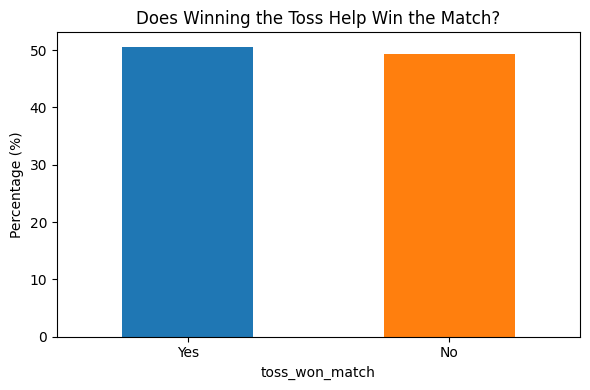

Toss winner won the match: 50.6%


In [4]:
df['toss_won_match'] = df['toss_winner'] == df['winner']
toss_impact = df['toss_won_match'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
toss_impact.plot(kind='bar', color=['#1f77b4','#ff7f0e'])
plt.title('Does Winning the Toss Help Win the Match?')
plt.xticks([0,1], ['Yes','No'], rotation=0)
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.savefig('toss_impact.png')
plt.show()

print(f"Toss winner won the match: {toss_impact[True]:.1f}%")

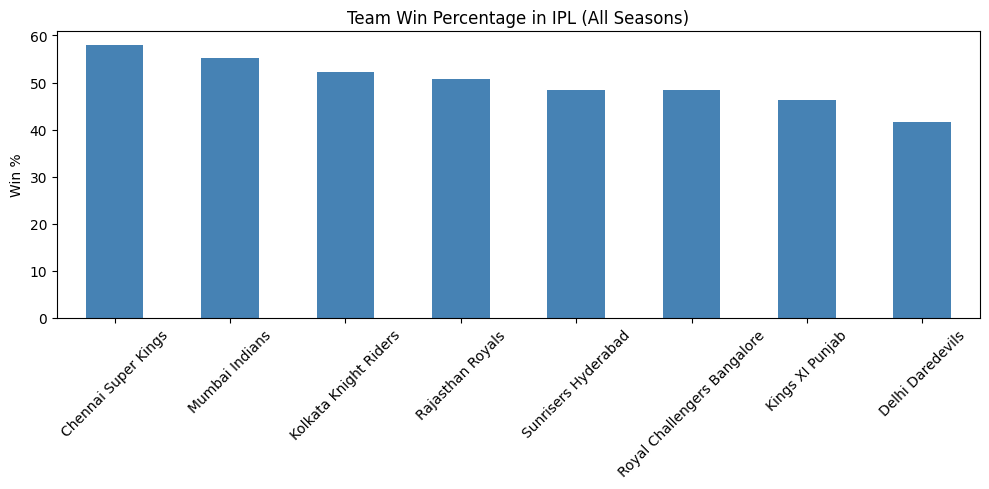

In [5]:
wins = df['winner'].value_counts().head(8)
matches = pd.concat([df['team1'], df['team2']]).value_counts()
win_pct = (wins / matches * 100).dropna().sort_values(ascending=False).head(8)

plt.figure(figsize=(10,5))
win_pct.plot(kind='bar', color='steelblue')
plt.title('Team Win Percentage in IPL (All Seasons)')
plt.ylabel('Win %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('team_win_pct.png')
plt.show()

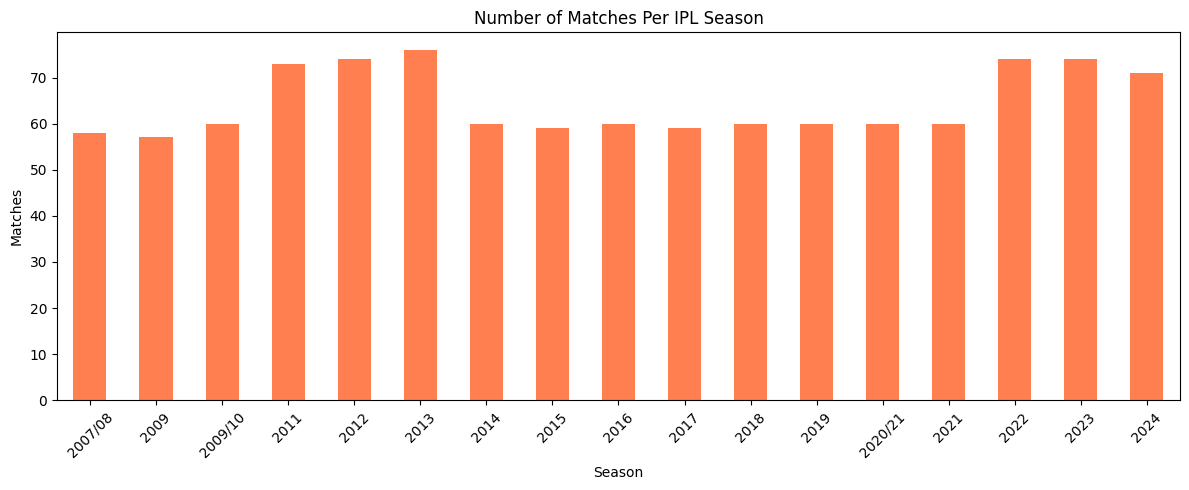

In [6]:
season_matches = df['season'].value_counts().sort_index()

plt.figure(figsize=(12,5))
season_matches.plot(kind='bar', color='coral')
plt.title('Number of Matches Per IPL Season')
plt.xlabel('Season')
plt.ylabel('Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('season_matches.png')
plt.show()

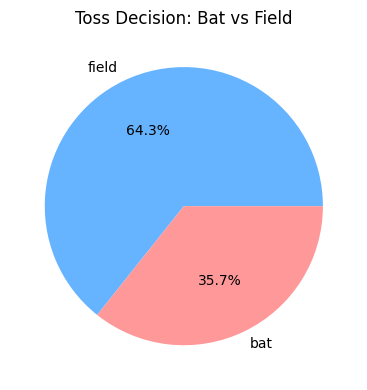

In [7]:
toss_decision = df['toss_decision'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
toss_decision.plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Toss Decision: Bat vs Field')
plt.ylabel('')
plt.tight_layout()
plt.savefig('toss_decision.png')
plt.show()

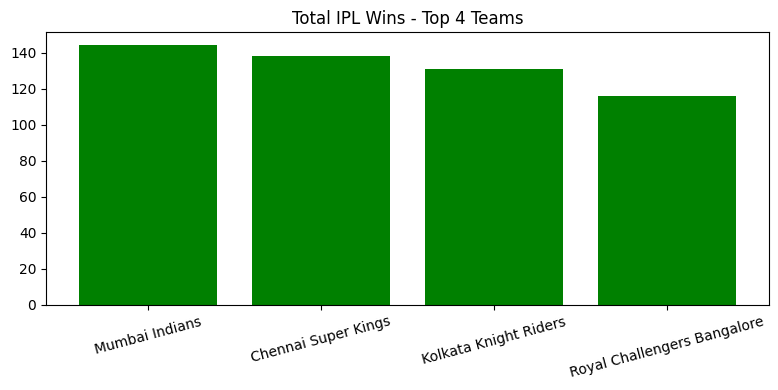

In [8]:
teams = ['Mumbai Indians', 'Chennai Super Kings', 'Kolkata Knight Riders', 'Royal Challengers Bangalore']

results = []
for team in teams:
    total_wins = len(df[df['winner'] == team])
    results.append({'Team': team, 'Total Wins': total_wins})

results_df = pd.DataFrame(results)
plt.figure(figsize=(8,4))
plt.bar(results_df['Team'], results_df['Total Wins'], color='green')
plt.title('Total IPL Wins - Top 4 Teams')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('top_teams.png')
plt.show()